# FLOODSENSE — STEP 3: BASELINE MODEL

LightGBM with `GroupKFold(n_splits=3)` grouped by district.

### Two variants for the `water_area_km2` leak test:
- **Model A (FULL):** all features including `water_area_*`
- **Model B (LEAN):** same minus `water_area_km2`, `water_area_change`, `water_area_pct_change`

### Decisions confirmed:
- `district` excluded as a feature (each fold's val district is unseen)
- Threshold for binary metrics = `0.5`
- `is_unbalance=True` to address class imbalance per brief

## Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

CLEAN_PATH = "processed/floodsense_clean.csv"
PLOTS_DIR  = "baseline_plots"
MODELS_DIR = "baseline_models"
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

THRESHOLD = 0.5

## Load Cleaned Data

In [2]:
df = pd.read_csv(CLEAN_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["district", "date"]).reset_index(drop=True)
print(f"Loaded: {df.shape}")
df.head()

Loaded: (1365, 23)


,date,evaporation,precipitation,pressure,soil_moisture,temperature,water_area_km2,wind_speed,humidity,precip_3day_avg,...,day_of_year,month,year,is_monsoon,water_area_change,water_area_pct_change,flood_event,district,avg_elevation_m,is_missing_precipitation
0,2023-01-01,-0.000230,0.000135,100639.5491,0.087776,16.712126,73.521606,0.625041,50.787158,0.000159,...,1.0,1,2023,0,-178.235539,-0.707966,0,Balochistan_District,610,0
1,2023-01-01,-0.000230,NaN,100639.5491,0.087776,16.712126,374.708945,0.625041,50.787158,0.000204,...,1.0,1,2023,0,301.187339,4.096583,0,Balochistan_District,610,1
2,2023-01-02,-0.000215,0.000000,100800.0680,0.087691,16.070381,250.390562,2.556115,54.975463,0.000090,...,2.0,1,2023,0,-124.318384,-0.331773,0,Balochistan_District,610,0
3,2023-01-03,-0.000217,0.000000,101029.1779,0.087694,15.405261,126.072178,2.904837,49.248183,0.000045,...,3.0,1,2023,0,-124.318384,-0.496498,0,Balochistan_District,610,0
4,2023-01-04,-0.000214,0.000000,101026.6490,0.087631,14.635752,1.753794,2.287333,51.012060,0.000000,...,4.0,1,2023,0,-124.318384,-0.986089,0,Balochistan_District,610,0


## Define Feature Sets

- **Full** → all numeric features (including `water_area_*`)
- **Lean** → same but with `water_area_*` columns removed to test for leakage

In [3]:
target = "flood_event"
exclude = ["date", target, "district"]   # district excluded as decided
feature_cols_full = [c for c in df.columns if c not in exclude]
water_area_cols   = ["water_area_km2", "water_area_change", "water_area_pct_change"]
feature_cols_lean = [c for c in feature_cols_full if c not in water_area_cols]

print(f"Model A (FULL) features ({len(feature_cols_full)}):")
print(f"  {feature_cols_full}")
print(f"\nModel B (LEAN) features ({len(feature_cols_lean)}):")
print(f"  {feature_cols_lean}")

Model A (FULL) features (20):
  ['evaporation', 'precipitation', 'pressure', 'soil_moisture', 'temperature', 'water_area_km2', 'wind_speed', 'humidity', 'precip_3day_avg', 'precip_7day_avg', 'temp_3day_avg', 'soil_3day_avg', 'day_of_year', 'month', 'year', 'is_monsoon', 'water_area_change', 'water_area_pct_change', 'avg_elevation_m', 'is_missing_precipitation']

Model B (LEAN) features (17):
  ['evaporation', 'precipitation', 'pressure', 'soil_moisture', 'temperature', 'wind_speed', 'humidity', 'precip_3day_avg', 'precip_7day_avg', 'temp_3day_avg', 'soil_3day_avg', 'day_of_year', 'month', 'year', 'is_monsoon', 'avg_elevation_m', 'is_missing_precipitation']


## Cross-Validation & LightGBM Setup

In [4]:
groups = df["district"]
group_kfold = GroupKFold(n_splits=3)
y = df[target].values

params = {
    "objective":        "binary",
    "metric":           "auc",
    "learning_rate":    0.05,
    "num_leaves":       31,
    "min_data_in_leaf": 20,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq":     5,
    "is_unbalance":     True,   # addresses 32/68 imbalance per brief
    "verbose":          -1,
    "random_state":     42,
}

print("LightGBM params:")
for k, v in params.items():
    print(f"  {k}: {v}")

LightGBM params:
  objective: binary
  metric: auc
  learning_rate: 0.05
  num_leaves: 31
  min_data_in_leaf: 20
  feature_fraction: 0.9
  bagging_fraction: 0.8
  bagging_freq: 5
  is_unbalance: True
  verbose: -1
  random_state: 42


## Training Function

Runs GroupKFold CV, collects out-of-fold predictions, and returns metrics + feature importance.

In [5]:
def train_baseline(feature_cols, variant_name):
    X = df[feature_cols].copy()

    oof_preds = np.zeros(len(df))
    fold_aucs, fold_districts, fold_imp, models = [], [], [], []

    print("\n" + "=" * 72)
    print(f"TRAINING {variant_name}")
    print("=" * 72)

    for fold, (tr_idx, vl_idx) in enumerate(group_kfold.split(X, y, groups), start=1):
        X_tr, X_vl = X.iloc[tr_idx], X.iloc[vl_idx]
        y_tr, y_vl = y[tr_idx], y[vl_idx]
        held_out = df.iloc[vl_idx]["district"].iloc[0]
        fold_districts.append(held_out)

        train_data = lgb.Dataset(X_tr, label=y_tr)
        val_data   = lgb.Dataset(X_vl, label=y_vl, reference=train_data)

        model = lgb.train(
            params,
            train_data,
            num_boost_round=1000,
            valid_sets=[val_data],
            valid_names=["val"],
            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)],
        )

        val_preds = model.predict(X_vl, num_iteration=model.best_iteration)
        oof_preds[vl_idx] = val_preds

        fold_auc = roc_auc_score(y_vl, val_preds)
        fold_aucs.append(fold_auc)
        fold_imp.append(model.feature_importance(importance_type="gain"))
        models.append(model)

        print(f"  Fold {fold} (held-out: {held_out:25s}): "
              f"AUC = {fold_auc:.4f}   best iter = {model.best_iteration}")

    # Overall metrics on out-of-fold predictions
    overall_auc = roc_auc_score(y, oof_preds)
    oof_bin = (oof_preds >= THRESHOLD).astype(int)
    acc  = accuracy_score(y, oof_bin)
    prec = precision_score(y, oof_bin)
    rec  = recall_score(y, oof_bin)
    f1   = f1_score(y, oof_bin)
    cm   = confusion_matrix(y, oof_bin)

    print(f"\n  Overall cross-district AUC: {overall_auc:.4f}  "
          f"(mean per-fold {np.mean(fold_aucs):.4f}, std {np.std(fold_aucs):.4f})")
    print(f"  Accuracy @ 0.5:  {acc:.4f}    (brief target: > 0.70)")
    print(f"  Precision:       {prec:.4f}")
    print(f"  Recall:          {rec:.4f}")
    print(f"  F1:              {f1:.4f}")
    print(f"\n  Confusion matrix:")
    print(f"                Predicted 0   Predicted 1")
    print(f"  Actual 0:        {cm[0,0]:>5d}        {cm[0,1]:>5d}")
    print(f"  Actual 1:        {cm[1,0]:>5d}        {cm[1,1]:>5d}")

    importance_df = pd.DataFrame({
        "feature":    feature_cols,
        "importance": np.mean(fold_imp, axis=0),
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    return dict(
        variant_name=variant_name, feature_cols=feature_cols,
        oof_preds=oof_preds, fold_aucs=fold_aucs, fold_districts=fold_districts,
        overall_auc=overall_auc, accuracy=acc, precision=prec, recall=rec, f1=f1,
        confusion_matrix=cm, importance_df=importance_df, models=models,
    )

## Train Model A — FULL (with `water_area_*`)

In [6]:
results_full = train_baseline(feature_cols_full, "MODEL A — FULL (with water_area_*)")


TRAINING MODEL A — FULL (with water_area_*)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	val's auc: 1
  Fold 1 (held-out: Sindh_District           ): AUC = 1.0000   best iter = 1
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	val's auc: 1
  Fold 2 (held-out: Balochistan_District     ): AUC = 1.0000   best iter = 1
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[35]	val's auc: 1
  Fold 3 (held-out: KP_District              ): AUC = 1.0000   best iter = 35

  Overall cross-district AUC: 0.8518  (mean per-fold 1.0000, std 0.0000)
  Accuracy @ 0.5:  0.7707    (brief target: > 0.70)
  Precision:       0.9850
  Recall:          0.2964
  F1:              0.4557

  Confusion matrix:
                Predicted 0   Predicted 1
  Actual 0:          921            2
  Actual 1:          311          131


## Train Model B — LEAN (without `water_area_*`)

In [7]:
results_lean = train_baseline(feature_cols_lean, "MODEL B — LEAN (without water_area_*)")


TRAINING MODEL B — LEAN (without water_area_*)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[137]	val's auc: 0.555836
  Fold 1 (held-out: Sindh_District           ): AUC = 0.5558   best iter = 137
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[5]	val's auc: 0.576775
  Fold 2 (held-out: Balochistan_District     ): AUC = 0.5768   best iter = 5
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[9]	val's auc: 0.594734
  Fold 3 (held-out: KP_District              ): AUC = 0.5947   best iter = 9

  Overall cross-district AUC: 0.5451  (mean per-fold 0.5758, std 0.0159)
  Accuracy @ 0.5:  0.6733    (brief target: > 0.70)
  Precision:       0.4857
  Recall:          0.1538
  F1:              0.2337

  Confusion matrix:
                Predicted 0   Predicted 1
  Actual 0:          851           72
  Actual 1:          374           68


## Leak Test Comparison — Model A vs Model B

> If Model A is significantly better than Model B, `water_area_*` is a leak.

In [8]:
print("\n" + "=" * 72)
print("LEAK TEST COMPARISON  (Model A vs Model B)")
print("=" * 72)

cmp = pd.DataFrame({
    "Metric":     ["Cross-district AUC", "Accuracy", "Precision", "Recall", "F1"],
    "Model A":    [f"{results_full['overall_auc']:.4f}",
                   f"{results_full['accuracy']:.4f}",
                   f"{results_full['precision']:.4f}",
                   f"{results_full['recall']:.4f}",
                   f"{results_full['f1']:.4f}"],
    "Model B":    [f"{results_lean['overall_auc']:.4f}",
                   f"{results_lean['accuracy']:.4f}",
                   f"{results_lean['precision']:.4f}",
                   f"{results_lean['recall']:.4f}",
                   f"{results_lean['f1']:.4f}"],
    "Difference": [f"{results_full['overall_auc'] - results_lean['overall_auc']:+.4f}",
                   f"{results_full['accuracy']    - results_lean['accuracy']:+.4f}",
                   f"{results_full['precision']   - results_lean['precision']:+.4f}",
                   f"{results_full['recall']      - results_lean['recall']:+.4f}",
                   f"{results_full['f1']          - results_lean['f1']:+.4f}"],
})
print(cmp.to_string(index=False))

print("\nPer-district held-out AUC:")
per_dist = pd.DataFrame({
    "District (held-out)": results_full["fold_districts"],
    "Model A":             [f"{a:.4f}" for a in results_full["fold_aucs"]],
    "Model B":             [f"{a:.4f}" for a in results_lean["fold_aucs"]],
})
print(per_dist.to_string(index=False))

auc_gap = results_full["overall_auc"] - results_lean["overall_auc"]
if auc_gap > 0.15:
    verdict = ("LIKELY LEAK — water_area_* contributes >0.15 AUC.\n"
               "  → Step 4: replace with LAGGED water_area features (yesterday's value\n"
               "    predicting today's flood). This is defensible at deployment time.")
elif auc_gap > 0.05:
    verdict = ("REAL SIGNAL with care — water_area_* helps notably but isn't dominant.\n"
               "  → Step 4: keep current features AND add lagged versions for safety.")
else:
    verdict = ("MINIMAL IMPACT — water_area_* contributes very little.\n"
               "  → Step 4: keep as-is, focus engineering effort elsewhere.")

print(f"\nVERDICT: {verdict}")


LEAK TEST COMPARISON  (Model A vs Model B)
            Metric Model A Model B Difference
Cross-district AUC  0.8518  0.5451    +0.3067
          Accuracy  0.7707  0.6733    +0.0974
         Precision  0.9850  0.4857    +0.4992
            Recall  0.2964  0.1538    +0.1425
                F1  0.4557  0.2337    +0.2220

Per-district held-out AUC:
 District (held-out) Model A Model B
      Sindh_District  1.0000  0.5558
Balochistan_District  1.0000  0.5768
         KP_District  1.0000  0.5947

VERDICT: LIKELY LEAK — water_area_* contributes >0.15 AUC.
  → Step 4: replace with LAGGED water_area features (yesterday's value
    predicting today's flood). This is defensible at deployment time.


## Plots

### Feature Importance — Model A vs Model B

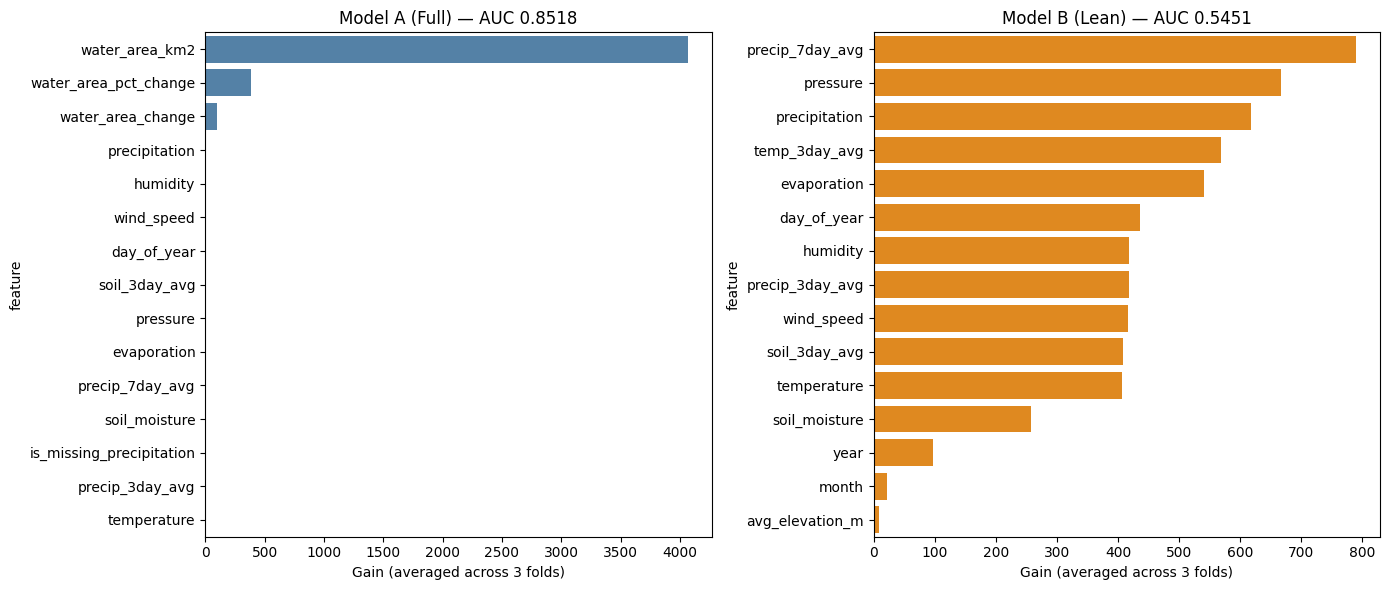

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, results, color, title in zip(
    axes,
    [results_full, results_lean],
    ["steelblue", "darkorange"],
    [f"Model A (Full) — AUC {results_full['overall_auc']:.4f}",
     f"Model B (Lean) — AUC {results_lean['overall_auc']:.4f}"],
):
    top = results["importance_df"].head(15)
    sns.barplot(data=top, x="importance", y="feature", color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Gain (averaged across 3 folds)")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/feature_importance.png", dpi=80)
plt.show()
plt.close()

### Confusion Matrices

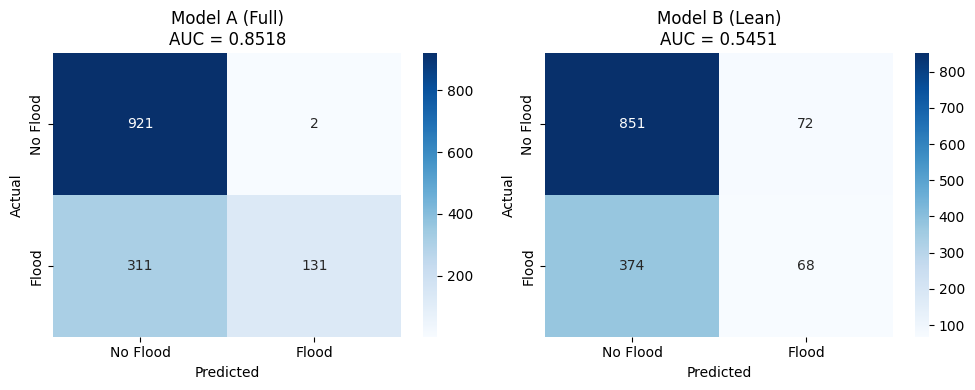

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, results, title in zip(
    axes,
    [results_full, results_lean],
    [f"Model A (Full)\nAUC = {results_full['overall_auc']:.4f}",
     f"Model B (Lean)\nAUC = {results_lean['overall_auc']:.4f}"],
):
    sns.heatmap(results["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Flood", "Flood"], yticklabels=["No Flood", "Flood"],
                ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/confusion_matrices.png", dpi=80)
plt.show()
plt.close()

### Per-District AUC Bar Plot

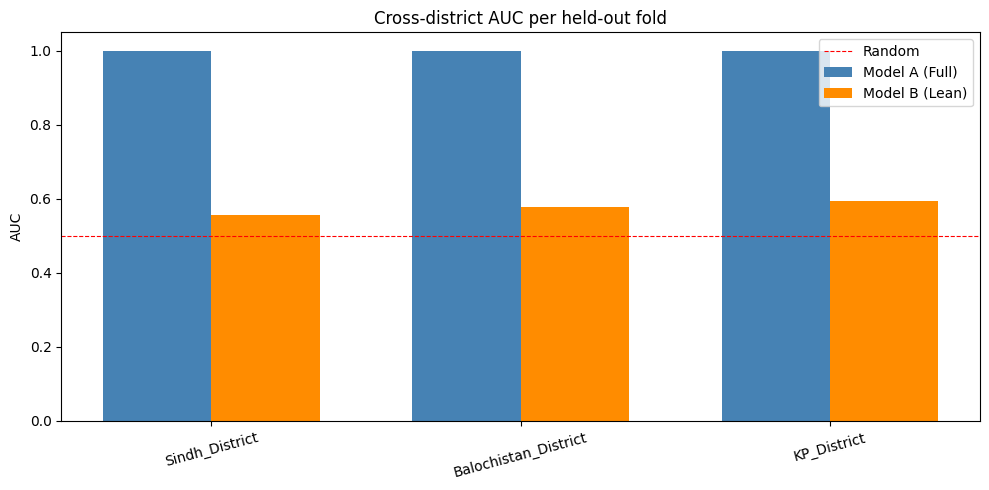

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_full["fold_districts"]))
width = 0.35
ax.bar(x - width/2, results_full["fold_aucs"], width, label="Model A (Full)", color="steelblue")
ax.bar(x + width/2, results_lean["fold_aucs"], width, label="Model B (Lean)", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(results_full["fold_districts"], rotation=15)
ax.set_ylabel("AUC")
ax.set_title("Cross-district AUC per held-out fold")
ax.axhline(y=0.5, color="red", linestyle="--", linewidth=0.8, label="Random")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/per_district_auc.png", dpi=80)
plt.show()
plt.close()

## Save Artifacts

In [12]:
np.save(f"{MODELS_DIR}/oof_preds_full.npy", results_full["oof_preds"])
np.save(f"{MODELS_DIR}/oof_preds_lean.npy", results_lean["oof_preds"])
results_full["importance_df"].to_csv(f"{MODELS_DIR}/feature_importance_full.csv", index=False)
results_lean["importance_df"].to_csv(f"{MODELS_DIR}/feature_importance_lean.csv", index=False)

for i, m in enumerate(results_full["models"], start=1):
    m.save_model(f"{MODELS_DIR}/lgb_full_fold{i}.txt")
for i, m in enumerate(results_lean["models"], start=1):
    m.save_model(f"{MODELS_DIR}/lgb_lean_fold{i}.txt")

print(f"Artifacts saved to:")
print(f"  Models  → {MODELS_DIR}/")
print(f"  Plots   → {PLOTS_DIR}/")

Artifacts saved to:
  Models  → baseline_models/
  Plots   → baseline_plots/


## Baseline Summary — Pitch Deck

In [13]:
print("\n" + "=" * 72)
print("BASELINE SUMMARY — for pitch deck")
print("=" * 72)
print(f"""
CV strategy:        GroupKFold(n_splits=3) grouped by district
                    (train on 2 districts, validate on the held-out 3rd)

Model A (Full):     AUC = {results_full['overall_auc']:.4f},  Accuracy = {results_full['accuracy']:.4f}
Model B (Lean):     AUC = {results_lean['overall_auc']:.4f},  Accuracy = {results_lean['accuracy']:.4f}
AUC gap:            {auc_gap:+.4f}  →  {verdict.split(chr(10))[0]}

Brief threshold (Accuracy > 0.70):
  Model A: {'PASS' if results_full['accuracy'] > 0.70 else 'FAIL'}
  Model B: {'PASS' if results_lean['accuracy'] > 0.70 else 'FAIL'}

Features by importance (Model A, top 5):
{results_full['importance_df'].head(5).to_string(index=False)}

Per-district held-out AUC:
{per_dist.to_string(index=False)}
""")


BASELINE SUMMARY — for pitch deck

CV strategy:        GroupKFold(n_splits=3) grouped by district
                    (train on 2 districts, validate on the held-out 3rd)

Model A (Full):     AUC = 0.8518,  Accuracy = 0.7707
Model B (Lean):     AUC = 0.5451,  Accuracy = 0.6733
AUC gap:            +0.3067  →  LIKELY LEAK — water_area_* contributes >0.15 AUC.

Brief threshold (Accuracy > 0.70):
  Model A: PASS
  Model B: FAIL

Features by importance (Model A, top 5):
              feature  importance
       water_area_km2 4063.680925
water_area_pct_change  383.489278
    water_area_change  102.582449
        precipitation    2.662275
             humidity    0.995237

Per-district held-out AUC:
 District (held-out) Model A Model B
      Sindh_District  1.0000  0.5558
Balochistan_District  1.0000  0.5768
         KP_District  1.0000  0.5947

